In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("cleaned_air_quality.csv")

In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])

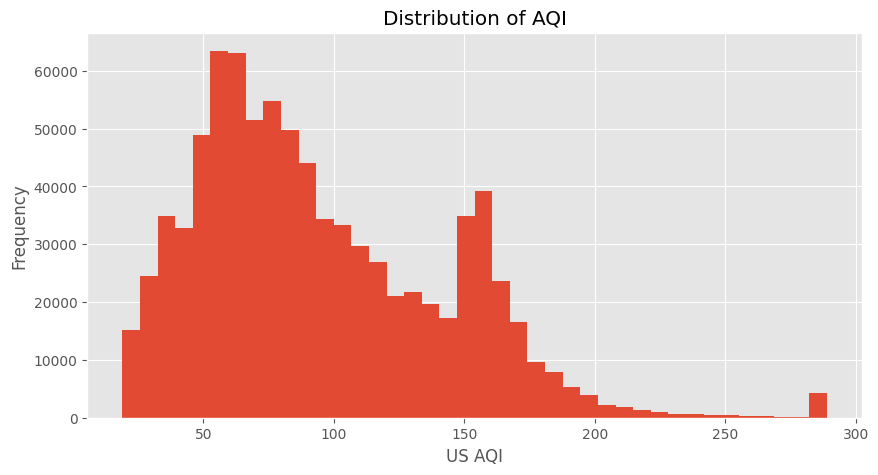

In [5]:
plt.figure(figsize=(10,5))

plt.hist(df["us_aqi"], bins=40)

plt.title("Distribution of AQI")
plt.xlabel("US AQI")
plt.ylabel("Frequency")

plt.show()

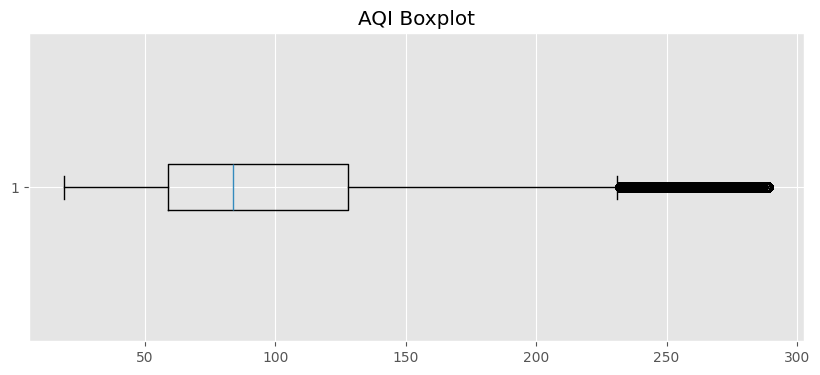

In [6]:
plt.figure(figsize=(10,4))

plt.boxplot(df["us_aqi"], vert=False)

plt.title("AQI Boxplot")

plt.show()

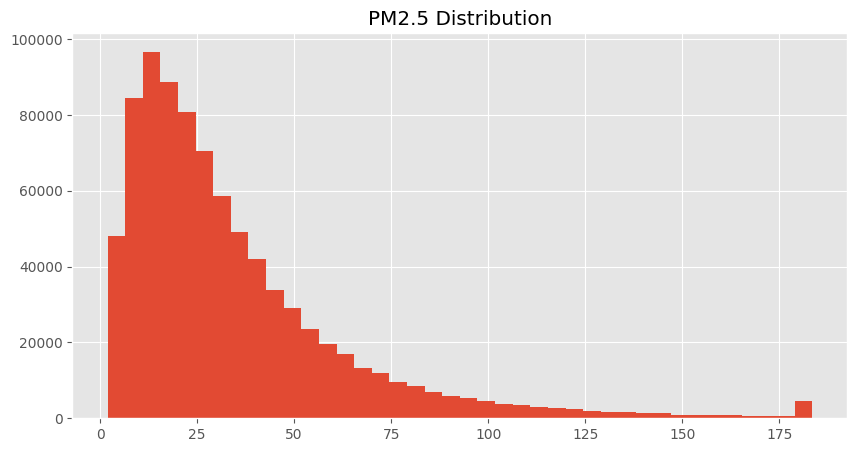

In [7]:
plt.figure(figsize=(10,5))

plt.hist(df["pm2_5_ugm3"], bins=40)

plt.title("PM2.5 Distribution")

plt.show()

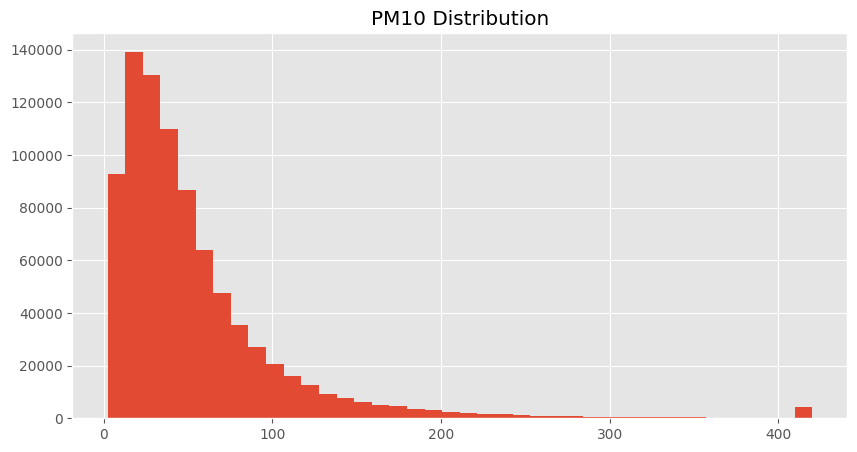

In [8]:
plt.figure(figsize=(10,5))

plt.hist(df["pm10_ugm3"], bins=40)

plt.title("PM10 Distribution")

plt.show()

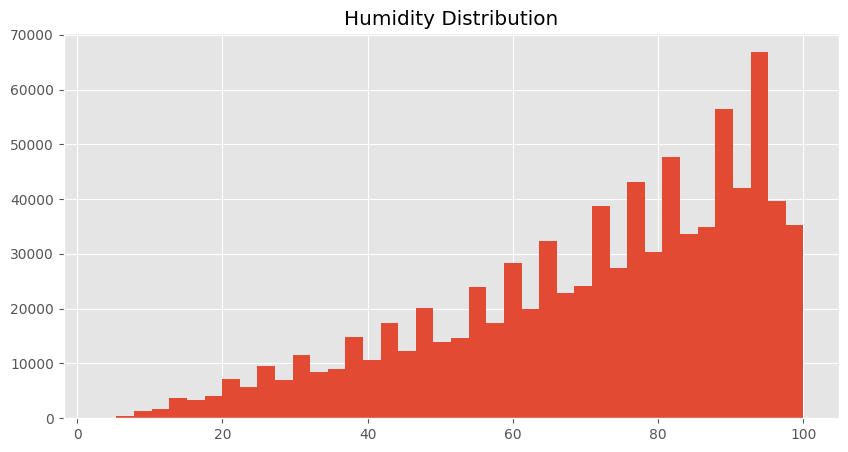

In [9]:
plt.figure(figsize=(10,5))

plt.hist(df["humidity_percent"], bins=40)

plt.title("Humidity Distribution")

plt.show()

# Time-Based Analysis



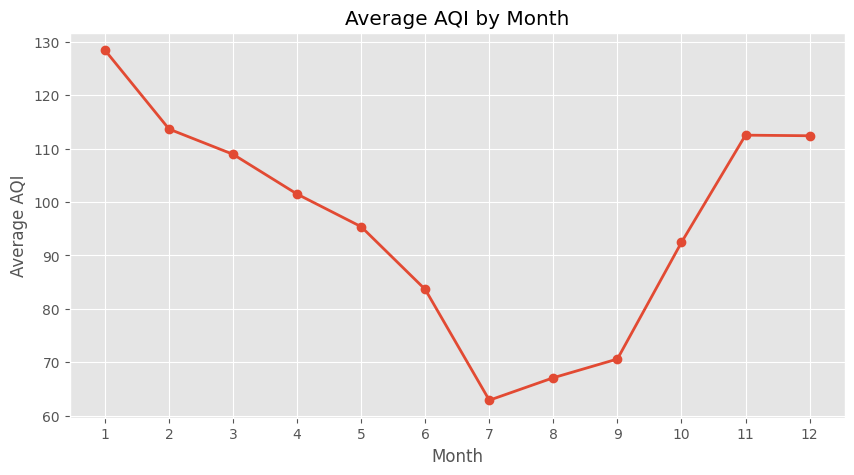

In [10]:
monthly_aqi = (
    df.groupby("month")["us_aqi"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_aqi["month"],
    monthly_aqi["us_aqi"],
    marker="o",
    linewidth=2
)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(range(1,13))

plt.show()

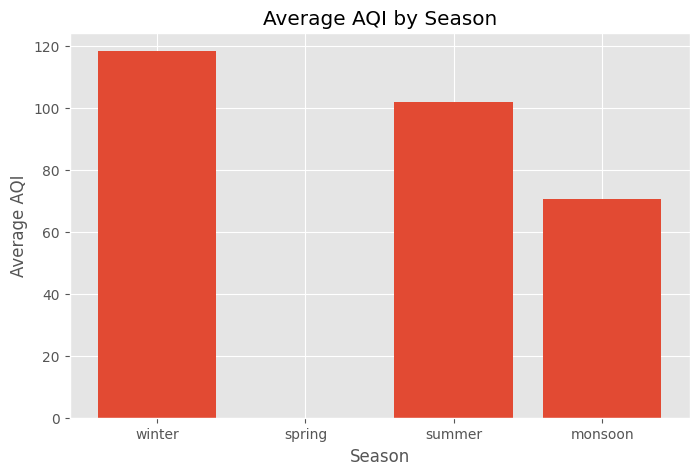

In [11]:
season_order = [
    "winter",
    "spring",
    "summer",
    "monsoon",
    "autumn"
]

season_aqi = (
    df.groupby("season")["us_aqi"]
      .mean()
      .reindex(season_order)
)

plt.figure(figsize=(8,5))

plt.bar(
    season_aqi.index,
    season_aqi.values
)

plt.title("Average AQI by Season")
plt.xlabel("Season")
plt.ylabel("Average AQI")

plt.show()

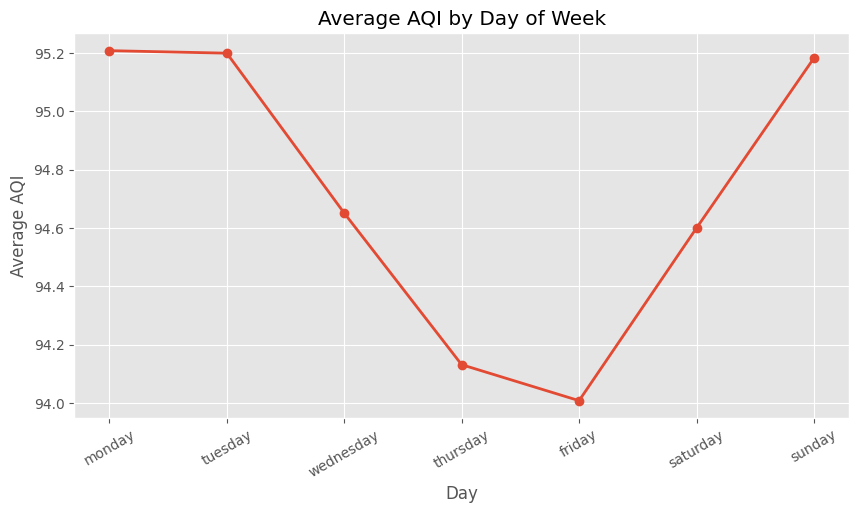

In [16]:
day_order = [
    "monday",
    "tuesday",
    "wednesday",
    "thursday",
    "friday",
    "saturday",
    "sunday"
]

day_aqi = (
    df.groupby("day_name")["us_aqi"]
      .mean()
      .reindex(day_order)
)

plt.figure(figsize=(10,5))

plt.plot(
    day_aqi.index,
    day_aqi.values,
    marker="o",
    linewidth=2
)

plt.title("Average AQI by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average AQI")

plt.xticks(rotation=30)

plt.show()

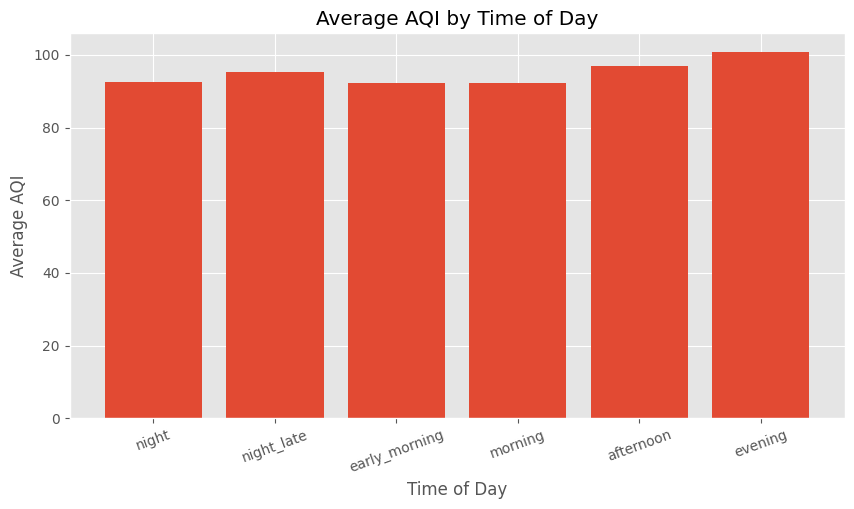

In [13]:
time_order = [
    "night",
    "night_late",
    "early_morning",
    "morning",
    "afternoon",
    "evening"
]

time_aqi = (
    df.groupby("time_of_day")["us_aqi"]
      .mean()
      .reindex(time_order)
)

plt.figure(figsize=(10,5))

plt.bar(
    time_aqi.index,
    time_aqi.values
)

plt.title("Average AQI by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average AQI")

plt.xticks(rotation=20)

plt.show()

/tmp/ipykernel_921/3229854104.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["us_aqi"]


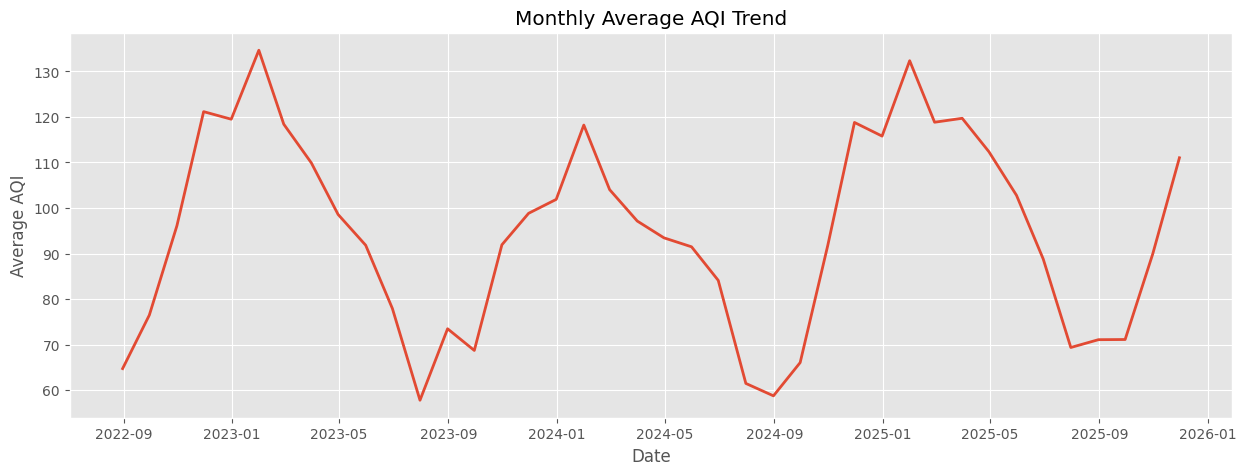

In [14]:
monthly_trend = (
    df.set_index("datetime")
      .resample("M")["us_aqi"]
      .mean()
)

plt.figure(figsize=(15,5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    linewidth=2
)

plt.title("Monthly Average AQI Trend")
plt.xlabel("Date")
plt.ylabel("Average AQI")

plt.show()


# Geographical Analysis

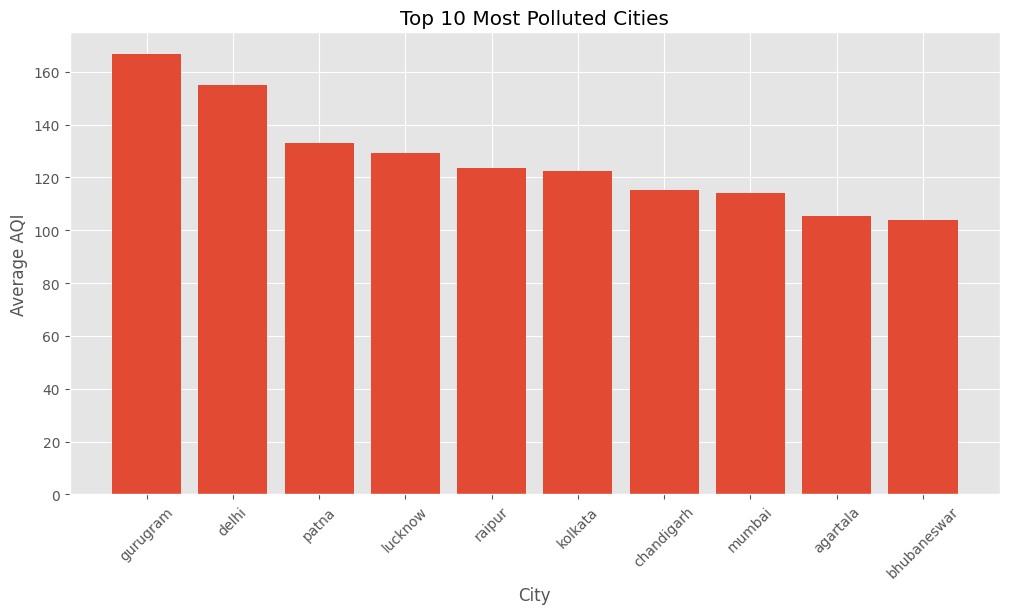

In [17]:
city_aqi = (
    df.groupby("city")["us_aqi"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(city_aqi.index, city_aqi.values)

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)

plt.show()

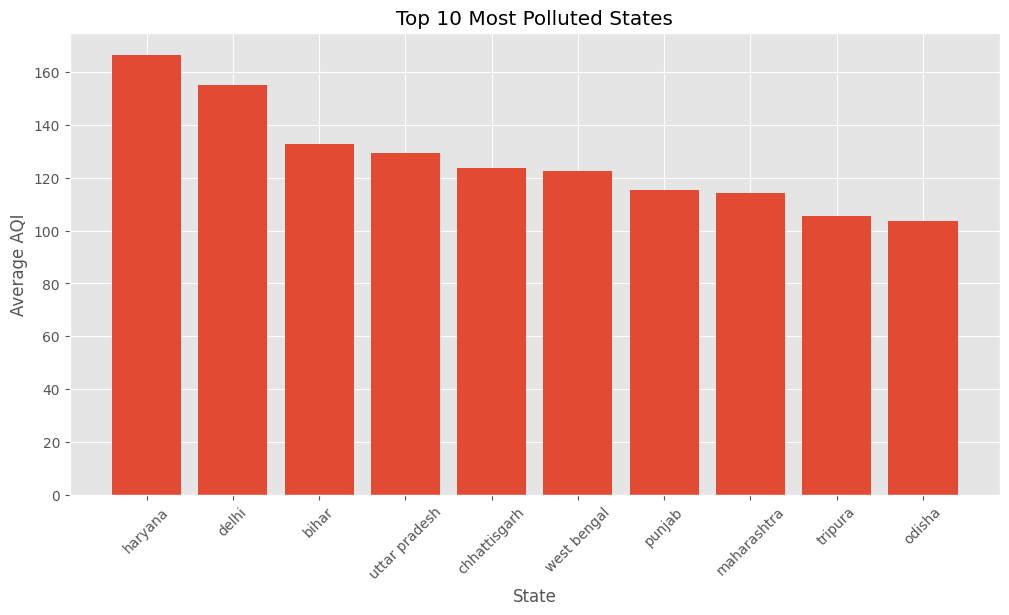

In [18]:
state_aqi = (
    df.groupby("state")["us_aqi"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(state_aqi.index, state_aqi.values)

plt.title("Top 10 Most Polluted States")
plt.xlabel("State")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)

plt.show()

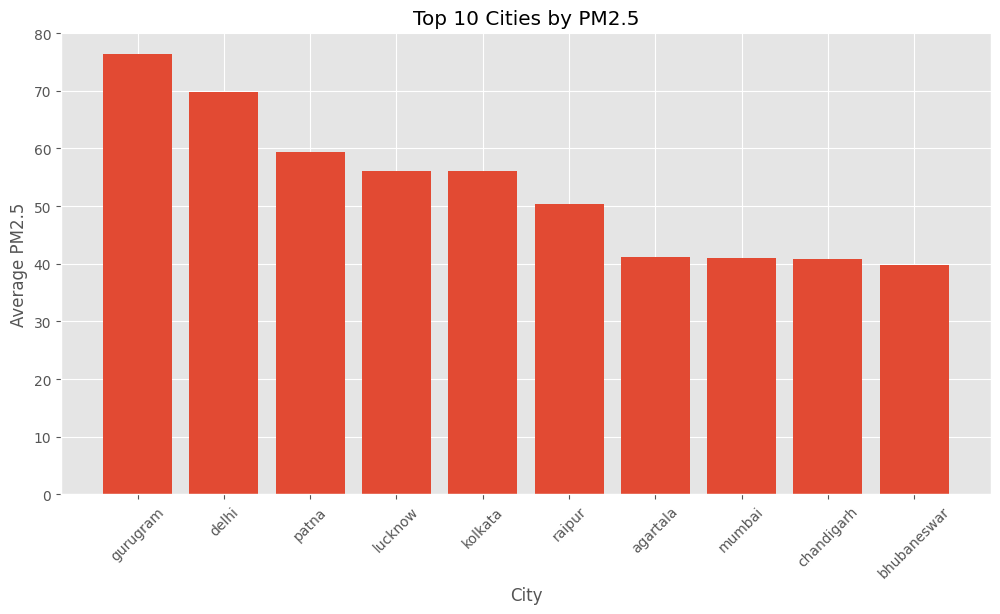

In [19]:
city_pm25 = (
    df.groupby("city")["pm2_5_ugm3"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(city_pm25.index, city_pm25.values)

plt.title("Top 10 Cities by PM2.5")
plt.xlabel("City")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=45)

plt.show()

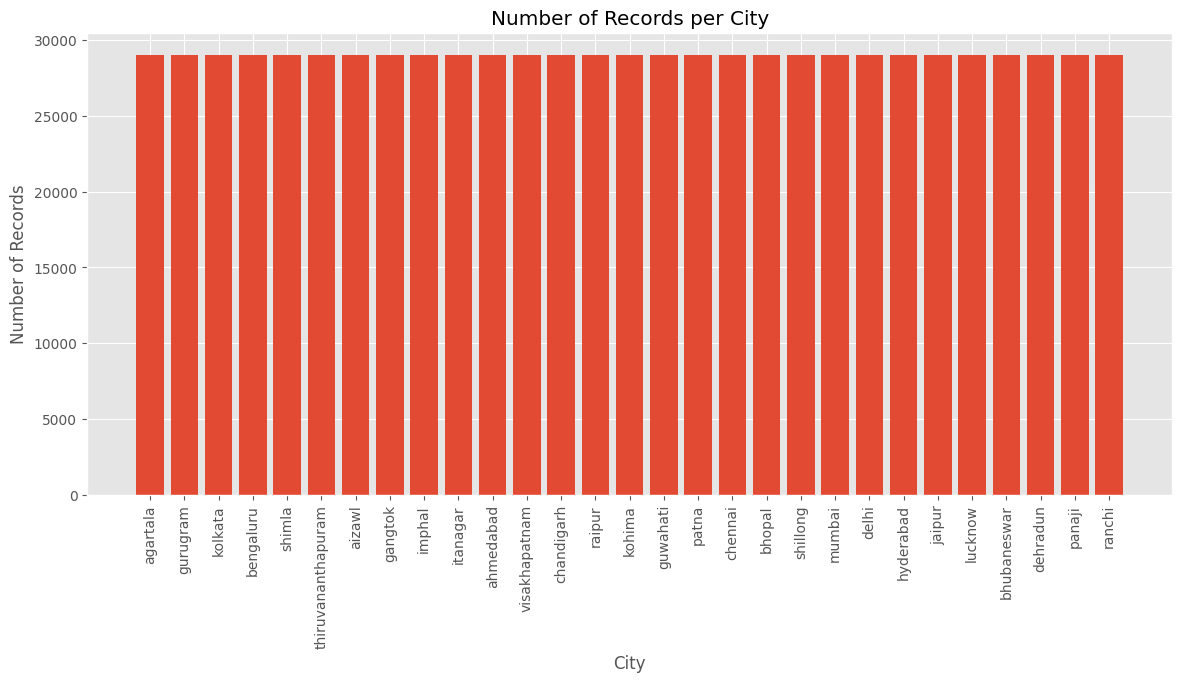

In [20]:
city_counts = df["city"].value_counts()

plt.figure(figsize=(14,6))

plt.bar(city_counts.index, city_counts.values)

plt.title("Number of Records per City")
plt.xlabel("City")
plt.ylabel("Number of Records")

plt.xticks(rotation=90)

plt.show()

# Correlation Analysis

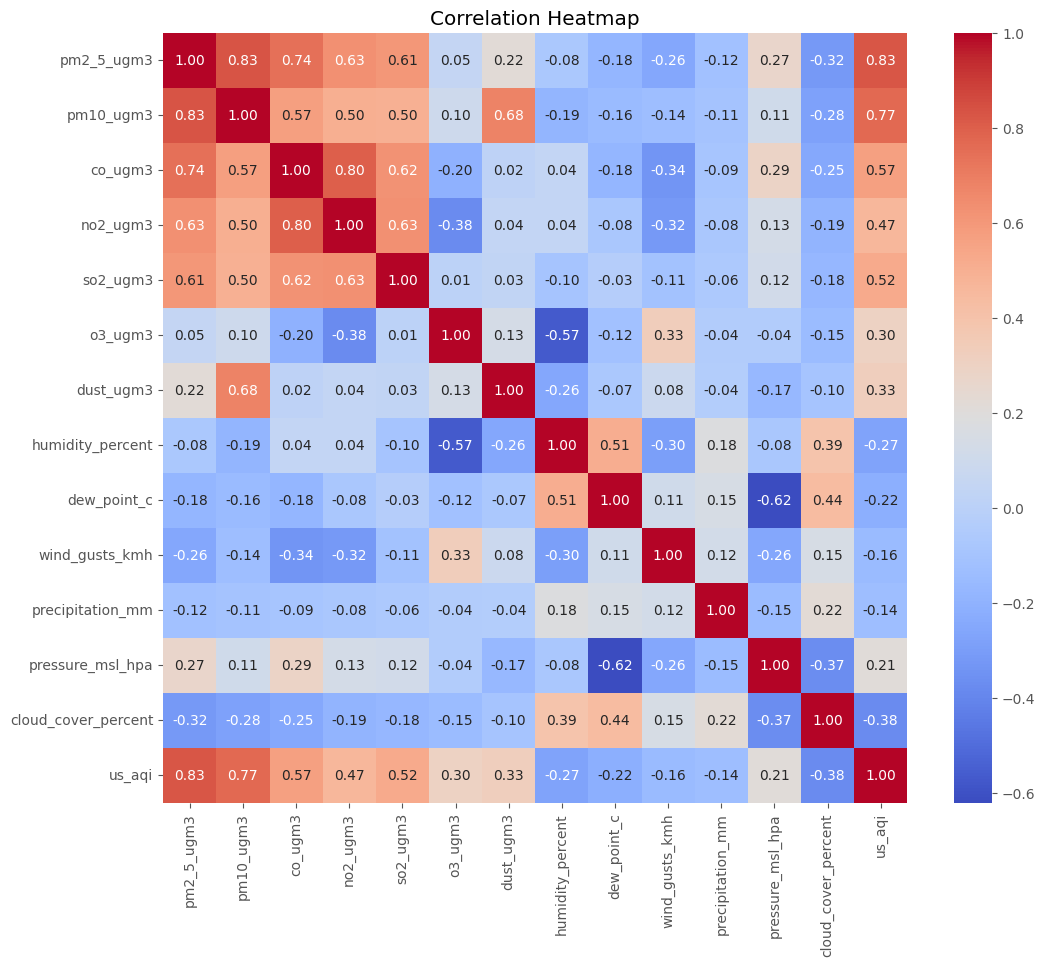

In [21]:
corr_cols = [
    "pm2_5_ugm3",
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "so2_ugm3",
    "o3_ugm3",
    "dust_ugm3",
    "humidity_percent",
    "dew_point_c",
    "wind_gusts_kmh",
    "precipitation_mm",
    "pressure_msl_hpa",
    "cloud_cover_percent",
    "us_aqi"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

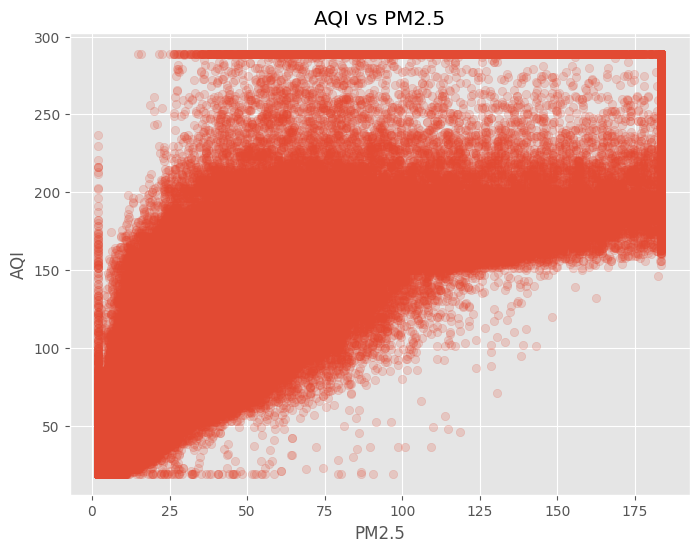

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["pm2_5_ugm3"],
    df["us_aqi"],
    alpha=0.2
)

plt.title("AQI vs PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

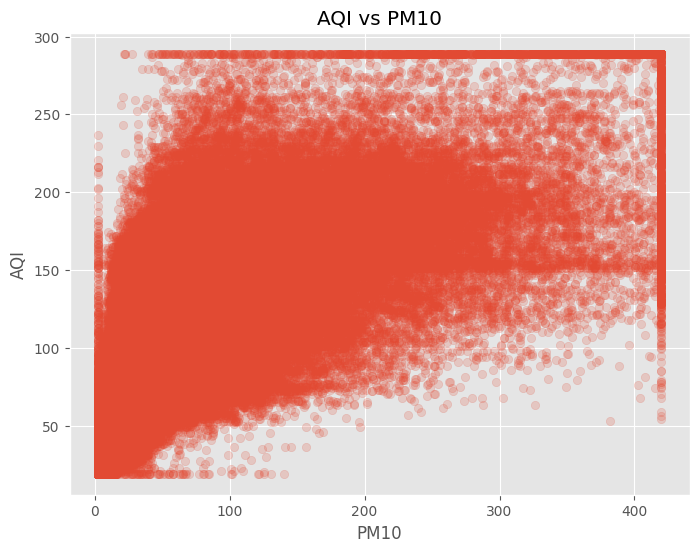

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["pm10_ugm3"],
    df["us_aqi"],
    alpha=0.2
)

plt.title("AQI vs PM10")
plt.xlabel("PM10")
plt.ylabel("AQI")

plt.show()

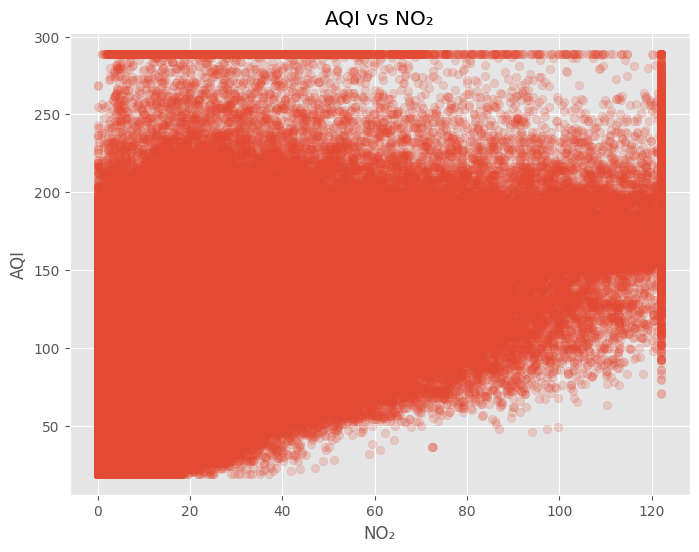

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["no2_ugm3"],
    df["us_aqi"],
    alpha=0.2
)

plt.title("AQI vs NO₂")
plt.xlabel("NO₂")
plt.ylabel("AQI")

plt.show()

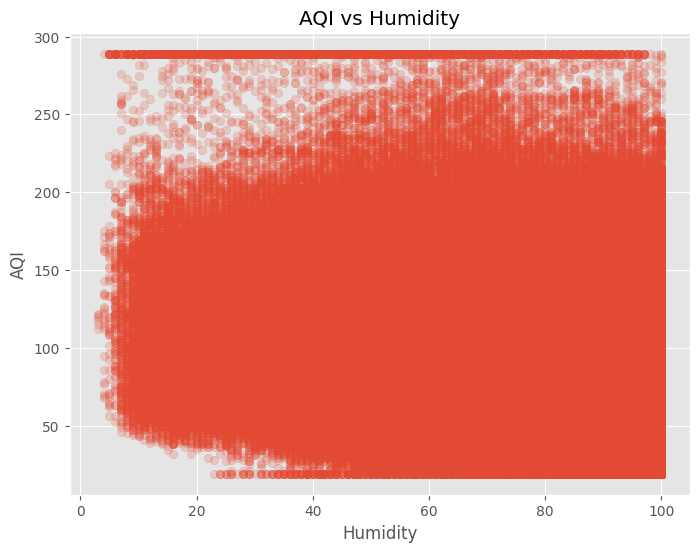

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["humidity_percent"],
    df["us_aqi"],
    alpha=0.2
)

plt.title("AQI vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("AQI")

plt.show()

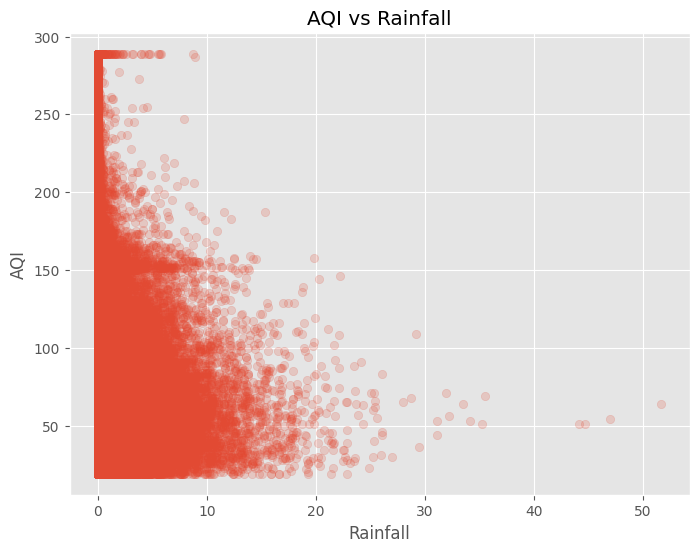

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["precipitation_mm"],
    df["us_aqi"],
    alpha=0.2
)

plt.title("AQI vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("AQI")

plt.show()

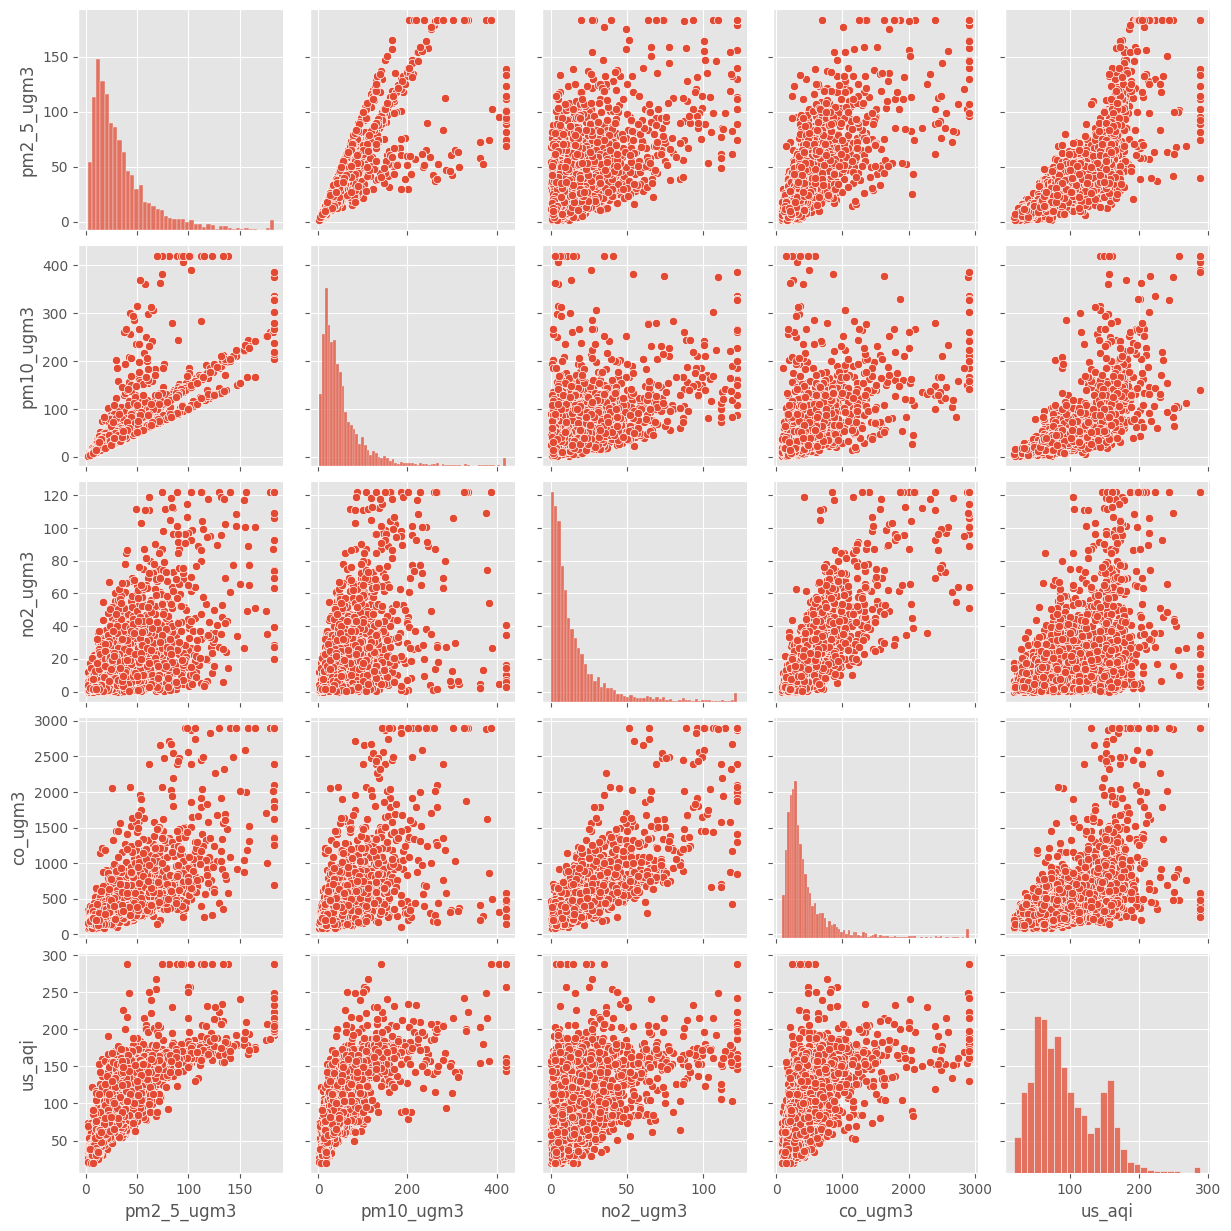

In [27]:
pair_df = df[
    [
        "pm2_5_ugm3",
        "pm10_ugm3",
        "no2_ugm3",
        "co_ugm3",
        "us_aqi"
    ]
].sample(3000, random_state=42)

sns.pairplot(pair_df)

plt.show()

# Exploratory Data Analysis Summary

## Key Findings

### Air Quality
- AQI is right-skewed with frequent pollution spikes.
- Outliers represent real pollution events and will be retained.

### Seasonal Trends
- Winter has the highest AQI.
- Monsoon has the lowest AQI.
- AQI increases sharply after October.

### Weekly Trends
- Day of the week has minimal impact on AQI.

### Time of Day
- Evening shows the highest average AQI.

### Geographical Trends
- Certain cities and states consistently experience higher pollution.
- These regions will be prioritized in the dashboard.

### Correlation
- PM2.5 and PM10 are expected to show the strongest relationship with AQI.
- Weather variables will be evaluated for predictive value.

## Conclusion

The dataset exhibits strong temporal, geographical, and pollutant-based patterns, making it suitable for building an AQI forecasting model.